# Random Forest Regression in Python

#### A random forest is an ensemble learning method that combines the predictions from multiple decision trees to produce a more accurate and stable prediction. It can be used for both classification and regression tasks. In a regression task, we can use the Random Forest Regression technique for predicting numerical values. It predicts continuous values by averaging the results of multiple decision trees.

## Working of Random Forest Regression

#### Random Forest Regression works by creating multiple of decision trees each trained on a random subset of the data. The process begins with Bootstrap sampling where random rows of data are selected with replacement to form different training datasets for each tree. After this we do feature sampling where only a random subset of features is used to build each tree ensuring diversity in the models.

#### After the trees are trained each tree make a prediction and the final prediction for regression tasks is the average of all the individual tree predictions and this process is called as Aggregation.

#### This approach is beneficial because individual decision trees may have high variance and are prone to overfitting especially with complex data. However by averaging the predictions from multiple decision trees Random Forest minimizes this variance leading to more accurate and stable predictions and hence improving generalization of model.



# Implementing Random Forest Regression in Python

### 1. Importing Libraries

**RandomForestRegressor:** This is the regression model that is based upon the Random Forest model.

**LabelEncoder:** This class is used to encode categorical data into numerical values.

**KNNImputer:** This class is used to impute missing values in a dataset using a k-nearest neighbors approach.

**train_test_split:** This function is used to split a dataset into training and testing sets.

**StandardScaler:** This class is used to standardize features by removing the mean and scaling to unit variance.

**f1_score:** This function is used to evaluate the performance of a classification model using the F1 score.

**RandomForestRegressor:** This class is used to train a random forest regression model.

**cross_val_score:** This function is used to perform k-fold cross-validation to evaluate the performance of a model



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

### 2. Importing Dataset

In [2]:
df= pd.read_csv('/Users/suraj/Downloads/Position_Salaries.csv')
print(df)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Position  10 non-null     str  
 1   Level     10 non-null     int64
 2   Salary    10 non-null     int64
dtypes: int64(2), str(1)
memory usage: 489.0 bytes


### 3. Data Preparation

#### Here the code will extracts two subsets of data from the Dataset and stores them in separate variables.

**Extracting Features:** It extracts the features from the DataFrame and stores them in a variable named X.

**Extracting Target Variable:** It extracts the target variable from the DataFrame and stores it in a variable named y.

In [4]:
X = df.iloc[:,1:2].values
y = df.iloc[:,2].values

### 4. Random Forest Regressor Model

#### The code processes categorical data by encoding it numerically, combines the processed data with numerical data and trains a Random Forest Regression model using the prepared data.

**RandomForestRegressor:** It builds multiple decision trees and combines their predictions.

**n_estimators=10:** Defines the number of decision trees in the Random Forest.

**random_state=0:** Ensures the randomness in model training is controlled for reproducibility.

**oob_score=True:** Enables out-of-bag scoring which evaluates the model's performance using data not seen by individual trees during training.

**LabelEncoder():** Converts categorical variables (object type) into numerical values, making them suitable for machine learning models.

**apply(label_encoder.fit_transform):** Applies the LabelEncoder transformation to each categorical column, converting string labels into numbers.

**concat():** Combines the numerical and encoded categorical features horizontally into one dataset which is then used as input for the model.



In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
x_categorical = df.select_dtypes(include=['object']).apply(label_encoder.fit_transform)
x_numerical = df.select_dtypes(exclude=['object']).values
x = pd.concat([pd.DataFrame(x_numerical), x_categorical], axis=1).values

regressor = RandomForestRegressor(n_estimators=10, random_state=0, oob_score=True)

regressor.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

### 5. Making predictions and Evaluating

#### The code evaluates the trained Random Forest Regression model:

**oob_score_:** Retrive out-of-bag (OOB) score which estimates the model's generalization performance.

Makes predictions using the trained model and stores them in the **'predictions'** array.

Evaluates the model's performance using the **Mean Squared Error (MSE)** and **R-squared (R2) metrics**.



In [6]:
from sklearn.metrics import mean_squared_error, r2_score

oob_score = regressor.oob_score_
print(f'Out-of-Bag Score: {oob_score}')

predictions = regressor.predict(x)

mse = mean_squared_error(y, predictions)
print(f'Mean Squared Error: {mse}')

r2 = r2_score(y, predictions)
print(f'R-squared: {r2}')

Out-of-Bag Score: 0.644879832593859
Mean Squared Error: 2647325000.0
R-squared: 0.9671801245316117


### 6. Visualizing

#### Now let's visualize the results obtained by using the RandomForest Regression model on our salaries dataset.

* Creates a grid of prediction points covering the range of the feature values.

* Plots the real data points as blue scatter points.

* Plots the predicted values for the prediction grid as a green line.

* Adds labels and a title to the plot for better understanding.

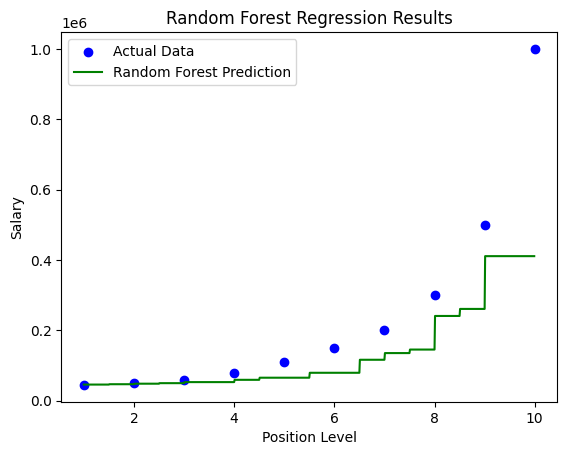

In [7]:
import numpy as np

X_grid = np.arange(min(X[:, 0]), max(X[:, 0]), 0.01)  # Only the first feature
X_grid = X_grid.reshape(-1, 1)
X_grid = np.hstack((X_grid, np.zeros((X_grid.shape[0], 2))))  # Pad with zeros

plt.scatter(X[:, 0], y, color='blue', label="Actual Data")
plt.plot(X_grid[:, 0], regressor.predict(X_grid), color='green', label="Random Forest Prediction")  
plt.title("Random Forest Regression Results")
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.show()

### 7. Visualizing a Single Decision Tree from the Random Forest Model

#### The code visualizes one of the decision trees from the trained Random Forest model. Plots the selected decision tree, displaying the decision-making process of a single tree within the ensemble.

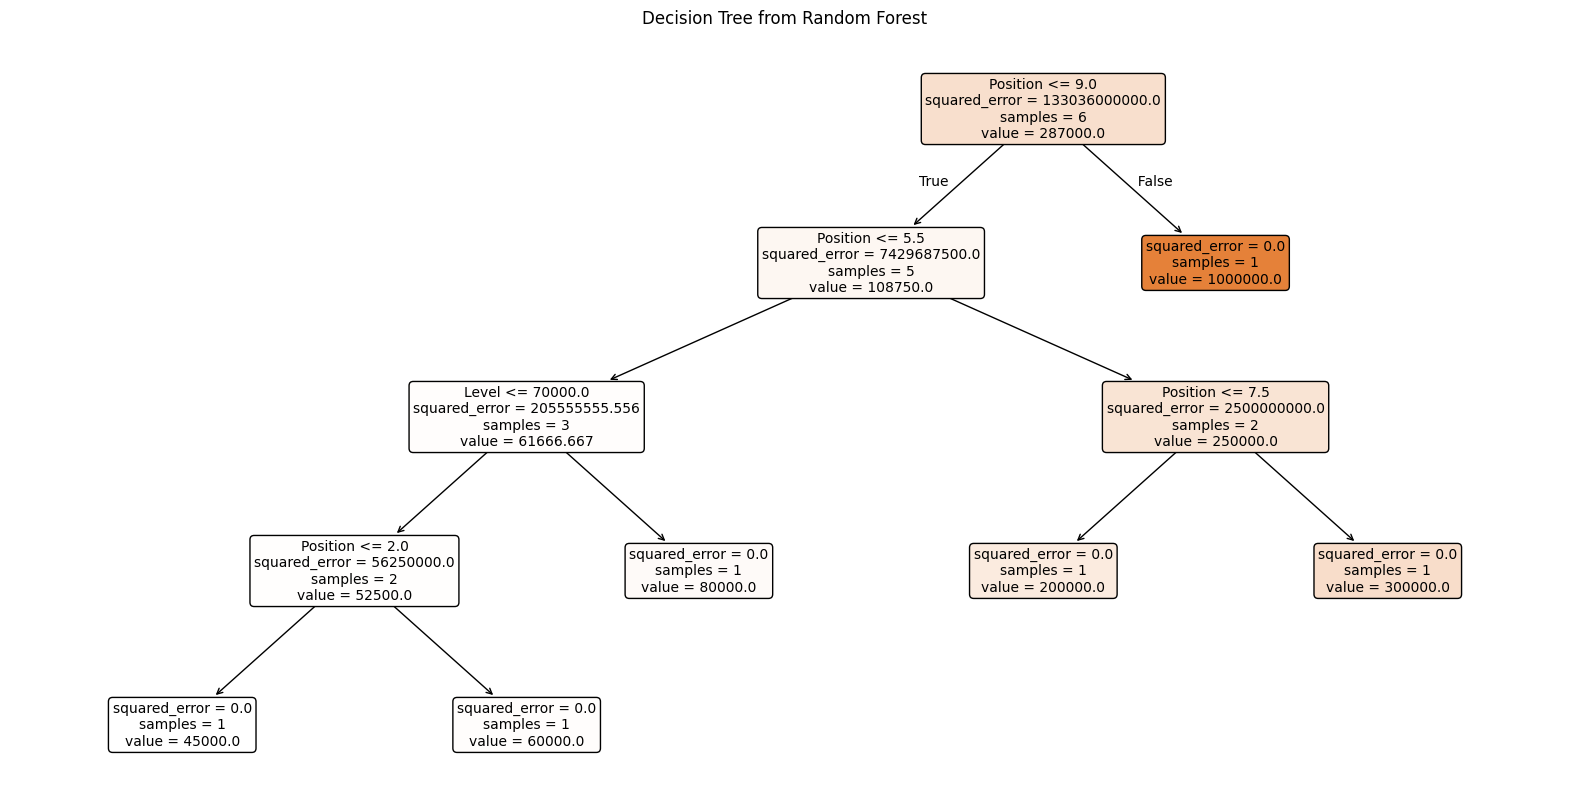

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = regressor.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_to_plot, feature_names=df.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree from Random Forest")
plt.show()